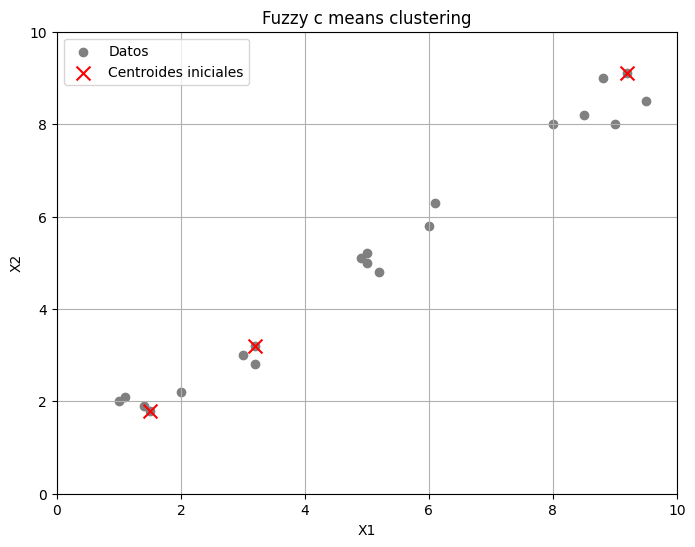

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# datos
x = np.array([
    [1.0, 2.0], [1.5, 1.8], [2.0, 2.2], [3.0, 3.0], [3.2, 2.8],
    [8.0, 8.0], [8.5, 8.2], [9.0, 8.0], [9.5, 8.5], [8.8, 9.0],
    [5.0, 5.0], [5.0, 5.2], [6.0, 5.8], [5.2, 4.8], [6.1, 6.3],
    [4.9, 5.1], [1.1, 2.1], [1.4, 1.9], [9.2, 9.1], [3.2, 3.2]
])

# Parametros
n = x.shape[0]  # N
c = 3  # Num de clusters
m = 2.0 # Dimensiones
max_iter = 100  # iteraciones
tol = 1e-4  # tolerancia

# Aqui inicializamos los centroides
np.random.seed(0)
indices = np.random.choice(n, c, replace=False)
centroids = x[indices] # tomamos valores aleatorios de x

# La convergencia es el cambio entre el centroide viejo y el nuevo
centroid_changes = []

# grafica inicial

plt.figure(figsize=(8, 6))
plt.title('Fuzzy c means clustering')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid()
plt.scatter(x[:, 0], x[:, 1], c='gray', marker='o', label='Datos')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=100, label='Centroides iniciales')
plt.legend()
plt.show()


In [2]:
for iteration in range(max_iter):
    # Calculamos la distancia entre x y el centroide
    d = np.linalg.norm(x[:, np.newaxis, :] - centroids, axis=2)
    d[d == 0] = 1e-10  # Evitamos la división por cero

    # Calculamos la matriz de pertenencia
    u = 1 / np.sum((d[:, :, np.newaxis] / d[:, np.newaxis, :]) ** (2 / (m - 1)), axis=2)

    # Actualizamos los centroides eficientemente
    denominator = np.sum(u ** m, axis=0) 
    numerator = np.dot((u ** m).T, x)  

    # Evitamos división por cero con np.where()
    new_centroids = np.where(denominator[:, np.newaxis] > 0, numerator / denominator[:, np.newaxis], centroids)

    # Guardamos la magnitud del cambio de los centroides
    change = np.linalg.norm(new_centroids - centroids)
    centroid_changes.append(change)

    # Condición de convergencia
    if change < tol:
        break

    centroids = new_centroids  # Actualizamos los centroides

# print(centroids)

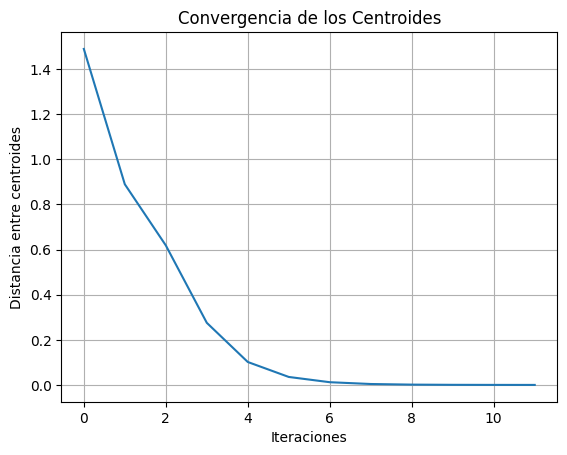

In [3]:
# Graficamos la convergencia de los centroides
plt.plot(range(len(centroid_changes)), centroid_changes, linestyle='-')
plt.title("Convergencia de los Centroides")
plt.xlabel("Iteraciones")
plt.ylabel("Distancia entre centroides")
plt.grid()
plt.show()



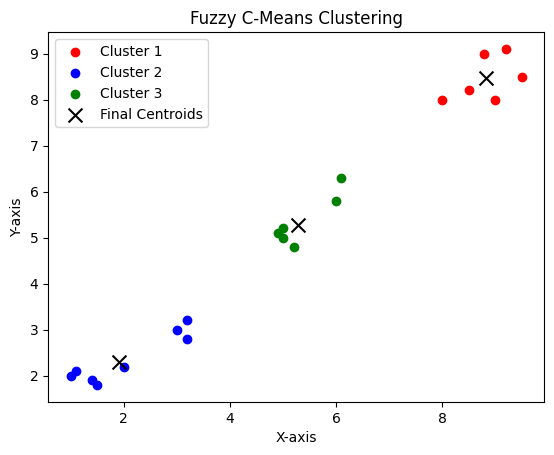

In [4]:
# Graficamos los puntos y los centroides finales
colors = ['red', 'blue', 'green']
for i in range(c):
    plt.scatter(x[u[:, i] > 0.5, 0], x[u[:, i] > 0.5, 1], c=colors[i], label=f'Cluster {i+1}')
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='x', s=100, label='Final Centroids')
plt.title("Fuzzy C-Means Clustering")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.show()

